In [2]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('/Users/user/Desktop/ml/analyze/bigdata/proj/to_github/dataset_megacleaned2.csv', index_col=0)
df = df[[i for i in df.columns if i not in ['service_fee_to_gmv_ratio', 'proportion']]]
df.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,region,gender_cd,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date
0,2025-05-04 21:00:00+00:00,1038898430,23,3299.69,1.0,Pro,6.0,WEBVIEW_IOS,51.89,2025-03-03,...,NaN,M,29.0,NaN,UNM,0.0,Пожарный,3299.69,63.590094,2025-03-03
1,2025-05-18 21:00:00+00:00,645418085,0,197.80,1.0,No Subscription,6.0,ANDROID,3.63,2024-02-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197.80,54.490358,2024-02-08
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4035.71,65.599967,2025-03-07
3,2025-05-18 21:00:00+00:00,610595698,23,1300.71,1.0,No Subscription,3.0,ANDROID,23.47,2024-03-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1300.71,55.420111,2024-03-03
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.77,57.440045,2025-01-31


In [4]:
df.columns

Index(['week', 'party_rk', 'service_fee_amt', 'gmv', 'orders_cnt',
       'bundle_name', 'cashback_category', 'platform', 'liters',
       'first_order_date', 'entries_cnt', 'region', 'gender_cd', 'age',
       'education_level_cd', 'marital_status_cd', 'children_cnt', 'job_title',
       'mean_price', 'meanperliter', 'fisrt_order_date'],
      dtype='object')

In [5]:
df['week'] = pd.to_datetime(df['week'])

In [6]:
df.shape

(448035, 21)

#### Делаем метрику retention 4weeks

In [7]:
from datetime import timedelta

user_weeks = df.groupby('party_rk')['week'].apply(list)

def returned_in_period(user, start_week, n_weeks):
    weeks = user_weeks[user]
    end_week = start_week + timedelta(weeks=n_weeks)
    # вернулся если есть ХОТЬ ОДНА запись между (start_week; end_week]
    return any((start_week < w <= end_week) for w in weeks)

In [8]:
df['retention_4weeks'] = df.apply(
    lambda r: returned_in_period(r['party_rk'], r['week'], 4),
    axis=1
)
df['retention_4weeks'] = df['retention_4weeks'].astype('int')

In [9]:
max_week = df['week'].max()
df.loc[df['week'] >= max_week - timedelta(weeks=3), 'retention_4weeks'] = None
df['retention_4weeks'].describe()

count    229395.000000
mean          0.929467
std           0.256044
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: retention_4weeks, dtype: float64

#### Ограничиваем период - 3 недели (с 06.04.2025 по 2025-04-20)

In [10]:
data = df[(df['week'] >= '2025-04-05') & (df['week'] <= '2025-04-21')]
data.week.unique()

<DatetimeArray>
['2025-04-06 21:00:00+00:00', '2025-04-13 21:00:00+00:00',
 '2025-04-20 21:00:00+00:00']
Length: 3, dtype: datetime64[ns, UTC]

#### Рассчитываем метрику

In [11]:
# средний сервисный сбор по пользователю
first_fee = (
    data.sort_values(['party_rk', 'week'])
      .groupby('party_rk')['service_fee_amt']
      .mean()
      .rename('first_service_fee')
)

# Средний чек = сумма gmv / сумма orders_cnt
avg_check = (
    data.groupby('party_rk')
      .apply(lambda x: x['gmv'].sum() / x['orders_cnt'].sum())
      .rename('avg_check')
)

# Собираем в одну таблицу
metrics = pd.concat([first_fee, avg_check], axis=1)

# Считаем итоговую метрику
metrics['service_fee_to_gmv_ratio'] = (
    metrics['first_service_fee'] / metrics['avg_check']
)

# Мержим обратно в исходный датафрейм
data = data.merge(
    metrics['service_fee_to_gmv_ratio'],
    left_on='party_rk',
    right_index=True,
    how='left'
)
data.head()

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_14731/2859674590.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['gmv'].sum() / x['orders_cnt'].sum())


,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,service_fee_to_gmv_ratio
2,2025-04-06 21:00:00+00:00,157611917,23,4035.71,1.0,Premium,7.0,IOS,61.52,2025-03-07,...,NaN,NaN,NaN,NaN,NaN,4035.71,65.599967,2025-03-07,1.0,0.005513
4,2025-04-13 21:00:00+00:00,1076685894,49,507.77,1.0,Pro,0.0,WEBVIEW_ANDROID,8.84,2025-01-31,...,NaN,NaN,NaN,NaN,NaN,507.77,57.440045,2025-01-31,0.0,0.043667
8,2025-04-06 21:00:00+00:00,391317842,19,314.19,1.0,No Subscription,0.0,IOS,5.07,2023-09-26,...,NaN,NaN,NaN,NaN,NaN,314.19,61.970414,2023-09-26,1.0,0.057163
9,2025-04-06 21:00:00+00:00,232066824,19,1378.61,1.0,Pro,0.0,ANDROID,25.53,2024-04-07,...,NaN,NaN,NaN,NaN,NaN,1378.61,53.999608,2024-04-07,1.0,0.017797
15,2025-04-06 21:00:00+00:00,402425070,19,4584.18,2.0,No Subscription,0.0,ANDROID,59.73,2025-04-08,...,NaN,NaN,NaN,NaN,NaN,2292.09,76.748368,2025-04-08,0.0,0.008289


<Axes: >

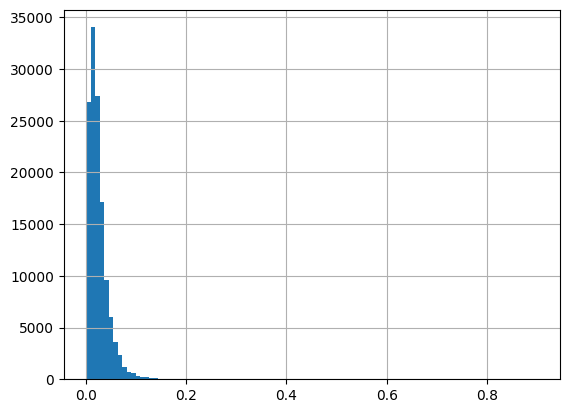

In [12]:
data['service_fee_to_gmv_ratio'].hist(bins=100)

<Axes: >

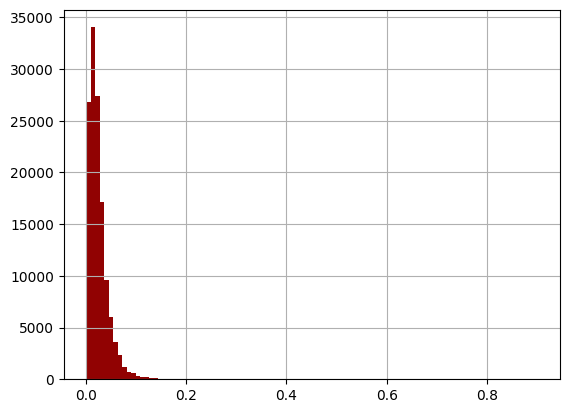

In [13]:
data['service_fee_to_gmv_ratio'].hist(bins=100, color='#910202')

<Axes: >

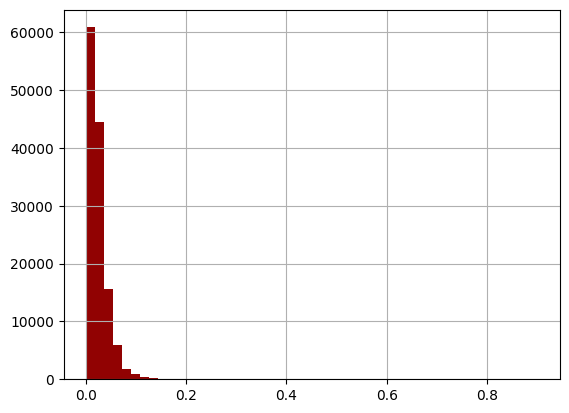

In [14]:
data['service_fee_to_gmv_ratio'].hist(bins=50, color='#910202')

#### Проводим линеаризацию

Линеаризованная метрика имеет вид:  

$$
L_i = Y_i − c * X_i
$$

Y_i = first_service_fee  
X_i = avg_check  
c — константа, которую нужно вычислить по всей выборке.

In [15]:
# Считаем константу c
c = metrics['first_service_fee'].sum() / metrics['avg_check'].sum()

# Линеаризация
metrics['service_fee_to_gmv_L'] = metrics['first_service_fee'] - c * metrics['avg_check']

In [16]:
data = data.merge(
    metrics[['service_fee_to_gmv_L']],
    left_on='party_rk',
    right_index=True,
    how='left'
)

Text(0.5, 0, 'service_fee_to_gmv_L')

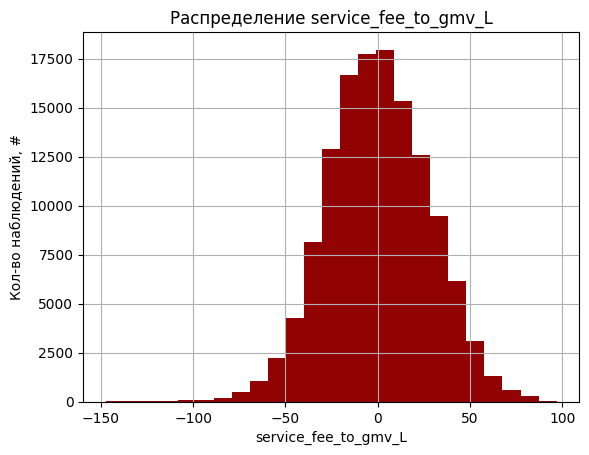

In [17]:
data[data.service_fee_to_gmv_L > -150].service_fee_to_gmv_L.hist(bins=25, color='#910202')
plt.title('Распределение service_fee_to_gmv_L')
plt.ylabel('Кол-во наблюдений, #')
plt.xlabel('service_fee_to_gmv_L')

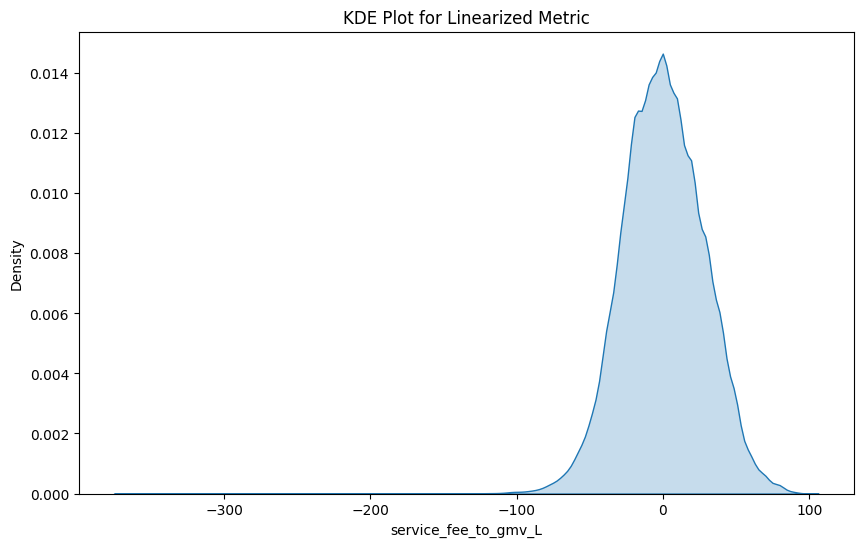

In [18]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data['service_fee_to_gmv_L'], 
    fill=True, 
    bw_adjust=1.2
)
plt.title("KDE Plot for Linearized Metric")
plt.xlabel("service_fee_to_gmv_L")
plt.ylabel("Density")
plt.show()

Смотрим на график, видим, что все супер - нет аномалий ratio-метрики, распределение очень красивенькое

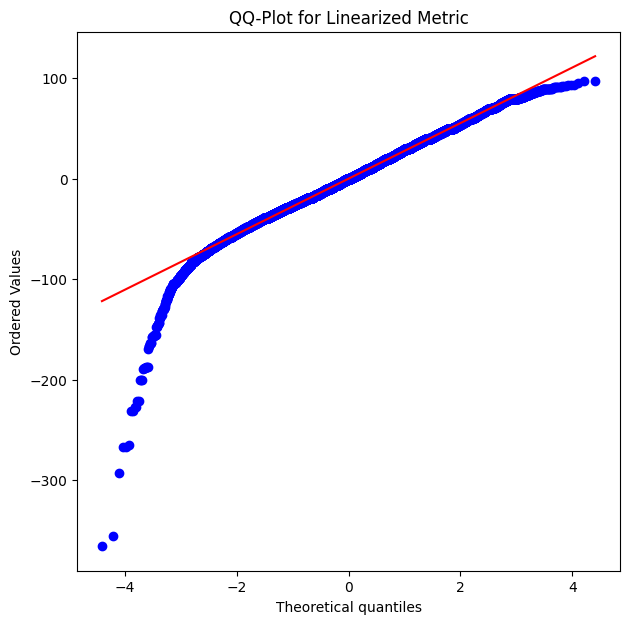

In [19]:
import scipy.stats as stats

plt.figure(figsize=(7, 7))
stats.probplot(data['service_fee_to_gmv_L'], dist="norm", plot=plt)
plt.title("QQ-Plot for Linearized Metric")
plt.show()


В целом на qq-plot тоже все более-менее нормально 

#### Делим пользователей на группы по линеаризованной метрике

In [20]:
q33 = data['service_fee_to_gmv_L'].quantile(0.33)
q67 = data['service_fee_to_gmv_L'].quantile(0.67)

def proportion_group(fee, l, q33, q67):
    if fee == 0:
        return 'no_fee'
    elif l <= q33:
        return 'low_fee'
    elif l <= q67:
        return 'medium_fee'
    else:
        return 'high_fee'

In [21]:
conditions = [
    data['service_fee_amt'] == 0,
    data['service_fee_to_gmv_L'] <= q33,
    data['service_fee_to_gmv_L'] <= q67
]

choices = ['no_fee', 'low_fee', 'medium_fee']
data['proportion'] = np.select(conditions, choices, default='high_fee')


In [22]:
data.proportion.head()

2        low_fee
4       high_fee
8       high_fee
9     medium_fee
15       low_fee
Name: proportion, dtype: object

#### Отбираем записи для подсчета retention

In [23]:
# оставляем последнюю запись для каждого пользователя, чтобы посчитать retention по ней
last_idx = data.groupby('party_rk')['week'].idxmax()
data = data.loc[last_idx].reset_index(drop=True)

In [24]:
data.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,service_fee_to_gmv_ratio,service_fee_to_gmv_L,proportion
0,2025-04-20 21:00:00+00:00,12103,29,2196.40,1.0,No Subscription,0.0,ANDROID,40.00,2024-05-07,...,NaN,NaN,NaN,2196.40,54.910000,2024-05-07,1.0,0.013203,-13.689601,low_fee
1,2025-04-20 21:00:00+00:00,14045,69,4427.30,2.0,Pro,0.0,ANDROID,71.80,2023-07-08,...,NaN,NaN,NaN,2213.65,61.661560,2023-07-08,1.0,0.022886,8.089775,medium_fee
2,2025-04-06 21:00:00+00:00,15150,29,2470.98,1.0,No Subscription,5.0,ANDROID,39.99,2024-05-16,...,NaN,NaN,NaN,2470.98,61.789947,2024-05-16,1.0,0.011736,-19.026384,low_fee
3,2025-04-06 21:00:00+00:00,17433,39,2479.60,1.0,Pro,3.0,ANDROID,40.00,2025-01-26,...,MAR,0.0,NaN,2479.60,61.990000,2025-01-26,1.0,0.015728,-9.193924,medium_fee
4,2025-04-20 21:00:00+00:00,22290,49,2583.60,1.0,Premium,0.0,ANDROID,40.00,2020-09-17,...,CIV,0.0,Водитель,2583.60,64.590000,2020-09-17,1.0,0.018207,-3.307589,medium_fee


In [25]:
data.shape

(73082, 25)

In [26]:
data.party_rk.nunique()

73082

#### Строим матмодель

In [27]:
data['retention_4weeks'] = data['retention_4weeks'].astype(int)
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']

retention_summary = data.groupby('proportion').agg(
    group_size=('retention_4weeks', 'count'),
    returned_count=('retention_4weeks', 'sum'),
    retention_rate=('retention_4weeks', 'mean')
).reset_index()

retention_summary['proportion'] = pd.Categorical(
    retention_summary['proportion'],
    categories=order,
    ordered=True
)

retention_summary = retention_summary.sort_values('proportion')

print(retention_summary)

   proportion  group_size  returned_count  retention_rate
3      no_fee        8764            7892        0.900502
1     low_fee       16247           14765        0.908783
2  medium_fee       23895           21491        0.899393
0    high_fee       24176           21154        0.875000


Супер! циферки просто отличные  

Теперь посмотрим стат тестами 

##### Хи-квадрат

In [28]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(data['proportion'], data['retention_4weeks'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi²:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi²: 140.11906455286805
p-value: 3.56276644734477e-30
Degrees of freedom: 3
Expected frequencies:
[[ 2573.67450261 21602.32549739]
 [ 1729.58676555 14517.41323445]
 [ 2543.76043349 21351.23956651]
 [  932.97829835  7831.02170165]]


Есть статзначимые отличия, значит какие-то группы все-таки отличаются :)

##### Z-test (попарные сравнения)

In [29]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

group_stats = data.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2     z_stat  p_value
0    high_fee     low_fee 0.875000 0.908783 -10.583567 0.000000
1    high_fee  medium_fee 0.875000 0.899393  -8.450487 0.000000
2    high_fee      no_fee 0.875000 0.900502  -6.334892 0.000000
3     low_fee  medium_fee 0.908783 0.899393   3.122935 0.001791
4     low_fee      no_fee 0.908783 0.900502   2.139869 0.032365
5  medium_fee      no_fee 0.899393 0.900502  -0.295576 0.767554


Все просто замечательно!! Нашли статзначимые отличия группы high_fee от остальных групп, значит действительно слишком высокое отношение сервисного сбора к среднему чеку пользователя влияет на отток :)

#### Проверка на устойчивость

##### retention в зависимости от сбора

**Сводные таблички**

In [30]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='service_fee_amt')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

mean                                               \
service_fee_amt       0        19       23       29       39       49   
proportion                                                              
no_fee          0.900502      NaN      NaN      NaN      NaN      NaN   
low_fee              NaN 0.915633 0.889802 0.911722 0.913939 0.902411   
medium_fee           NaN 0.909982 0.875536 0.899037 0.899712 0.902675   
high_fee             NaN 0.914812 0.835052 0.869159 0.885597 0.861321   

                                                              
service_fee_amt       59       69       79       89       99  
proportion                                                    
no_fee               NaN      NaN      NaN      NaN      NaN  
low_fee         0.912322 0.935897 0.857143 0.866667 1.000000  
medium_fee      0.902771 0.901018 0.955556 0.918367 0.846154  
high_fee        0.877017 0.883675 0.866419 0.837766 0.851101

In [31]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['count'], columns='service_fee_amt')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

count                                                  \
service_fee_amt          0           19          23          29          39   
proportion                                                                    
no_fee          8764.000000         NaN         NaN         NaN         NaN   
low_fee                 NaN 6045.000000 3285.000000 3455.000000 1894.000000   
medium_fee              NaN 4488.000000 3029.000000 4982.000000 4507.000000   
high_fee                NaN 1303.000000  194.000000  642.000000 2430.000000   

                                                                             \
service_fee_amt          49          59          69          79          89   
proportion                                                                    
no_fee                  NaN         NaN         NaN         NaN         NaN   
low_fee          871.000000  422.000000  234.000000   21.000000   15.000000   
medium_fee      3514.000000 2129.000000 1081.000000   90.000000   49.000000   
high_fee        4103.000000 5578.000000 6585.000000 1078.000000 1128.000000   

                             
service_fee_amt          99  
proportion                   
no_fee                  NaN  
low_fee            5.000000  
medium_fee        26.000000  
high_fee        1135.000000

**Стат тесты**

Уровень значимости - 0.05/3 = 0.01667

In [32]:
# нужно бы провести стат тесты
# для каждой группы по сервисному сбору (именно по service_fee_amt) считаем хи-квадрат для трех групп по proportion - МНЕ ЛЕНЬ ЭТО ДЕЛАТЬ СКИПАЕМ БРАТЬЯ
# если p-value < 0.05 (тут же не надо поправку делать?), то считаем z-тест для нахождения конкретных отличий
groups = [i for i in data['service_fee_amt'].unique() if i != 0]

In [33]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

In [34]:
for group in groups:

    curr = data[data['service_fee_amt'] == group]
    
    group_stats = curr.groupby('proportion').agg(
        returned_count=('retention_4weeks', 'sum'),
        total=('retention_4weeks', 'count')
    )

    results = []

    for g1, g2 in combinations(group_stats.index, 2):
        count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
        nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
        z_stat, p_val = proportions_ztest(count, nobs)

        results.append({
            "group_1": g1,
            "group_2": g2,
            "ret_1": count[0] / nobs[0],
            "ret_2": count[1] / nobs[1],
            "z_stat": z_stat,
            "p_value": p_val
        })

    results_df = pd.DataFrame(results)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print(f'Для группы service_fee_amt = {group}')
    print(results_df)
    print('\n')

Для группы service_fee_amt = 29
    group_1     group_2    ret_1    ret_2    z_stat  p_value
0  high_fee     low_fee 0.869159 0.911722 -3.378429 0.000729
1  high_fee  medium_fee 0.869159 0.899037 -2.330416 0.019784
2   low_fee  medium_fee 0.911722 0.899037  1.947116 0.051521


Для группы service_fee_amt = 69
    group_1     group_2    ret_1    ret_2    z_stat  p_value
0  high_fee     low_fee 0.883675 0.935897 -2.465080 0.013698
1  high_fee  medium_fee 0.883675 0.901018 -1.663606 0.096191
2   low_fee  medium_fee 0.935897 0.901018  1.667471 0.095421


Для группы service_fee_amt = 39
    group_1     group_2    ret_1    ret_2    z_stat  p_value
0  high_fee     low_fee 0.885597 0.913939 -3.055373 0.002248
1  high_fee  medium_fee 0.885597 0.899712 -1.827708 0.067593
2   low_fee  medium_fee 0.913939 0.899712  1.762991 0.077902


Для группы service_fee_amt = 49
    group_1     group_2    ret_1    ret_2    z_stat  p_value
0  high_fee     low_fee 0.861321 0.902411 -3.259256 0.001117
1  high_fee 

In [36]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

power_analysis = NormalIndPower()
alpha = 0.05 / 3  # уровень значимости

for group in groups:
    curr = data[data['service_fee_amt'] == group]
    
    group_stats = curr.groupby('proportion').agg(
        returned_count=('retention_4weeks', 'sum'),
        total=('retention_4weeks', 'count')
    )

    results = []

    for g1, g2 in combinations(group_stats.index, 2):
        count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
        nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
        
        # Z-тест
        z_stat, p_val = proportions_ztest(count, nobs)
        
        # доли
        p1 = count[0] / nobs[0]
        p2 = count[1] / nobs[1]
        
        # размер эффекта
        effect_size = proportion_effectsize(p1, p2)
        
        # чувствительность 
        power = power_analysis.solve_power(
            effect_size=effect_size,
            nobs1=nobs[0],
            alpha=alpha,
            ratio=nobs[1]/nobs[0],
            alternative='two-sided'
        )

        results.append({
            "group_1": g1,
            "group_2": g2,
            "ret_1": p1,
            "ret_2": p2,
            "z_stat": z_stat,
            "p_value": p_val,
            "power": power
        })

    results_df = pd.DataFrame(results)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print(f'Для группы service_fee_amt = {group}')
    print(results_df)
    print('\n')


Для группы service_fee_amt = 29
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.869159 0.911722 -3.378429 0.000729 0.785525
1  high_fee  medium_fee 0.869159 0.899037 -2.330416 0.019784 0.434948
2   low_fee  medium_fee 0.911722 0.899037  1.947116 0.051521 0.331682


Для группы service_fee_amt = 69
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.883675 0.935897 -2.465080 0.013698 0.645914
1  high_fee  medium_fee 0.883675 0.901018 -1.663606 0.096191 0.245864
2   low_fee  medium_fee 0.935897 0.901018  1.667471 0.095421 0.268803


Для группы service_fee_amt = 39
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.885597 0.913939 -3.055373 0.002248 0.755632
1  high_fee  medium_fee 0.885597 0.899712 -1.827708 0.067593 0.280534
2   low_fee  medium_fee 0.913939 0.899712  1.762991 0.077902 0.272483


Для группы service_fee_amt = 49
    group_1     group_2   

**вот тут делим до 49 и после 49**

In [55]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='fee_real')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

mean                                             
fee_real          0       19       23       29       39      49+
proportion                                                      
no_fee     0.900502      NaN      NaN      NaN      NaN      NaN
low_fee         NaN 0.915633 0.889802 0.911722 0.913939 0.909439
medium_fee      NaN 0.909982 0.875536 0.899037 0.899712 0.903034
high_fee        NaN 0.914812 0.835052 0.869159 0.885597 0.871627

In [40]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

power_analysis = NormalIndPower()
alpha = 0.05 / 3  # уровень значимости

groups_small = [i for i in groups if i < 49]

for group in groups_small:
    curr = data[data['service_fee_amt'] == group]
    
    group_stats = curr.groupby('proportion').agg(
        returned_count=('retention_4weeks', 'sum'),
        total=('retention_4weeks', 'count')
    )

    results = []

    for g1, g2 in combinations(group_stats.index, 2):
        count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
        nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
        
        # Z-тест
        z_stat, p_val = proportions_ztest(count, nobs)
        
        # доли
        p1 = count[0] / nobs[0]
        p2 = count[1] / nobs[1]
        
        # размер эффекта
        effect_size = proportion_effectsize(p1, p2)
        
        # чувствительность 
        power = power_analysis.solve_power(
            effect_size=effect_size,
            nobs1=nobs[0],
            alpha=alpha,
            ratio=nobs[1]/nobs[0],
            alternative='two-sided'
        )

        results.append({
            "group_1": g1,
            "group_2": g2,
            "ret_1": p1,
            "ret_2": p2,
            "z_stat": z_stat,
            "p_value": p_val,
            "power": power
        })

    results_df = pd.DataFrame(results)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print(f'Для группы service_fee_amt = {group}')
    print(results_df)
    print('\n')

Для группы service_fee_amt = 29
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.869159 0.911722 -3.378429 0.000729 0.785525
1  high_fee  medium_fee 0.869159 0.899037 -2.330416 0.019784 0.434948
2   low_fee  medium_fee 0.911722 0.899037  1.947116 0.051521 0.331682


Для группы service_fee_amt = 39
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.885597 0.913939 -3.055373 0.002248 0.755632
1  high_fee  medium_fee 0.885597 0.899712 -1.827708 0.067593 0.280534
2   low_fee  medium_fee 0.913939 0.899712  1.762991 0.077902 0.272483


Для группы service_fee_amt = 23
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.835052 0.889802 -2.338346 0.019369 0.407994
1  high_fee  medium_fee 0.835052 0.875536 -1.642292 0.100529 0.201446
2   low_fee  medium_fee 0.889802 0.875536  1.761637 0.078131 0.263230


Для группы service_fee_amt = 19
    group_1     group_2   

In [39]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower

power_analysis = NormalIndPower()
alpha = 0.05 / 3  # уровень значимости


curr = data[data['service_fee_amt'] >= 49]
    
group_stats = curr.groupby('proportion').agg(
        returned_count=('retention_4weeks', 'sum'),
        total=('retention_4weeks', 'count')
    )

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
        
    # Z-тест
    z_stat, p_val = proportions_ztest(count, nobs)
        
    # доли
    p1 = count[0] / nobs[0]
    p2 = count[1] / nobs[1]
        
    # размер эффекта
    effect_size = proportion_effectsize(p1, p2)
        
    # чувствительность 
    power = power_analysis.solve_power(
            effect_size=effect_size,
            nobs1=nobs[0],
            alpha=alpha,
            ratio=nobs[1]/nobs[0],
            alternative='two-sided'
        )

    results.append({
            "group_1": g1,
            "group_2": g2,
            "ret_1": p1,
            "ret_2": p2,
            "z_stat": z_stat,
            "p_value": p_val,
            "power": power
        })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(f'Для группы service_fee_amt >= 49')
print(results_df)
print('\n')

Для группы service_fee_amt >= 49
    group_1     group_2    ret_1    ret_2    z_stat  p_value    power
0  high_fee     low_fee 0.871627 0.909439 -4.347896 0.000014 0.987349
1  high_fee  medium_fee 0.871627 0.903034 -6.895345 0.000000 0.999999
2   low_fee  medium_fee 0.909439 0.903034  0.777835 0.436667 0.054590




##### По подпискам

**Сводные таблички**

In [43]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='bundle_name')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

mean                           
bundle_name No Subscription  Premium  Private      Pro
proportion                                            
no_fee             0.890499 0.919255 0.936508 0.909744
low_fee            0.902203 0.918534 0.636364 0.910761
medium_fee         0.892272 0.906173 0.846154 0.905744
high_fee           0.868357 0.897863 0.833333 0.877539

In [44]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['count'], columns='bundle_name')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

count                      
bundle_name No Subscription Premium Private   Pro
proportion                                       
no_fee                 4694     805      63  3202
low_fee                6401    3302      11  6533
medium_fee            11297    2835      13  9750
high_fee              11835    2340       6  9995

**Стат тесты**

Хочется посмотреть, отличаются ли подписчики pro и premium. Если нет, то объединяем их в одну категорию :)

In [45]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

In [46]:
# какие группы сравниваем
fee_groups = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']

results = []

for fee in fee_groups:
    # данные по Premium
    d1 = data[(data['bundle_name'] == 'Premium') & (data['proportion'] == fee)]
    count1 = d1['retention_4weeks'].sum()
    nobs1 = d1['retention_4weeks'].count()

    # данные по Pro
    d2 = data[(data['bundle_name'] == 'Pro') & (data['proportion'] == fee)]
    count2 = d2['retention_4weeks'].sum()
    nobs2 = d2['retention_4weeks'].count()

    # Z-test
    z_stat, p_val = proportions_ztest([count1, count2], [nobs1, nobs2])

    results.append({
        "fee_group": fee,
        "premium_ret": count1 / nobs1 if nobs1 > 0 else None,
        "pro_ret": count2 / nobs2 if nobs2 > 0 else None,
        "premium_count": count1,
        "premium_total": nobs1,
        "pro_count": count2,
        "pro_total": nobs2,
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)


    fee_group  premium_ret  pro_ret  premium_count  premium_total  pro_count  \
0      no_fee     0.919255 0.909744            740            805       2913   
1     low_fee     0.918534 0.910761           3033           3302       5950   
2  medium_fee     0.906173 0.905744           2569           2835       8831   
3    high_fee     0.897863 0.877539           2101           2340       8771   

   pro_total   z_stat  p_value  
0       3202 0.849976 0.395339  
1       6533 1.294245 0.195581  
2       9750 0.068882 0.945084  
3       9995 2.737231 0.006196  


Делаем поправку на множественные сравнения (их 4), 0.05/4 = 0.0125. Вообще-то все, кроме high_fee не статзначимо, так что давайте забьем на high_fee и объединим выборки.

Посмотрим уже отдельно с подпиской (любой) / без подписки

In [47]:
with_subs = data[(data['bundle_name'] == 'Pro') | (data['bundle_name'] == 'Premium')]
no_subs = data[data.bundle_name == 'No Subscription']

In [48]:
# для людей с подпиской 
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']

retention_summary = with_subs.groupby('proportion').agg(
    group_size=('retention_4weeks', 'count'),
    returned_count=('retention_4weeks', 'sum'),
    retention_rate=('retention_4weeks', 'mean')
).reset_index()

retention_summary['proportion'] = pd.Categorical(
    retention_summary['proportion'],
    categories=order,
    ordered=True
)

retention_summary = retention_summary.sort_values('proportion')

print(retention_summary)

   proportion  group_size  returned_count  retention_rate
3      no_fee        4007            3653        0.911655
1     low_fee        9835            8983        0.913371
2  medium_fee       12585           11400        0.905840
0    high_fee       12335           10872        0.881394


In [49]:
# для людей с подпиской
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

group_stats = with_subs.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.881394 0.913371 -7.734926 0.000000
1    high_fee  medium_fee 0.881394 0.905840 -6.260907 0.000000
2    high_fee      no_fee 0.881394 0.911655 -5.293807 0.000000
3     low_fee  medium_fee 0.913371 0.905840  1.946776 0.051562
4     low_fee      no_fee 0.913371 0.911655  0.324667 0.745433
5  medium_fee      no_fee 0.905840 0.911655 -1.104978 0.269169


In [50]:
# для людей без подписки
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']

retention_summary = no_subs.groupby('proportion').agg(
    group_size=('retention_4weeks', 'count'),
    returned_count=('retention_4weeks', 'sum'),
    retention_rate=('retention_4weeks', 'mean')
).reset_index()

retention_summary['proportion'] = pd.Categorical(
    retention_summary['proportion'],
    categories=order,
    ordered=True
)

retention_summary = retention_summary.sort_values('proportion')

print(retention_summary)

   proportion  group_size  returned_count  retention_rate
3      no_fee        4694            4180        0.890499
1     low_fee        6401            5775        0.902203
2  medium_fee       11297           10080        0.892272
0    high_fee       11835           10277        0.868357


In [53]:
# для людей без подписки
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

group_stats = no_subs.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.868252 0.902857 -6.819330 0.000000
1    high_fee  medium_fee 0.868252 0.892848 -5.717865 0.000000
2    high_fee      no_fee 0.868252 0.890905 -3.938382 0.000082
3     low_fee  medium_fee 0.902857 0.892848  2.084317 0.037131
4     low_fee      no_fee 0.902857 0.890905  2.038161 0.041534
5  medium_fee      no_fee 0.892848 0.890905  0.358285 0.720130


**короче мы нашли прикол, что есть люди, у которых подписка менялась за 3 недели**  

давайте чтобы однозначно было просто дропнем таких людей (их немного)

In [42]:
df_3weeks = df[(df['week'] >= '2025-04-05') & (df['week'] <= '2025-04-21')]

In [44]:
ch = df_3weeks.groupby('party_rk', as_index=False).agg({'bundle_name': 'nunique'})[df_3weeks.groupby('party_rk', as_index=False).agg({'bundle_name': 'nunique'})['bundle_name'] > 1]['party_rk']

In [45]:
curr = data[~data['party_rk'].isin(ch)]
curr.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,service_fee_to_gmv_ratio,service_fee_to_gmv_L,proportion
0,2025-04-20 21:00:00+00:00,12103,29,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,NaN,NaN,NaN,2196.400000,54.910000,2024-05-07,1,0.013203,-13.689601,low_fee
1,2025-04-20 21:00:00+00:00,14045,69,4427.300000,2.000000,Pro,0.000000,ANDROID,71.800000,2023-07-08,...,NaN,NaN,NaN,2213.650000,61.661560,2023-07-08,1,0.022886,8.089775,medium_fee
2,2025-04-06 21:00:00+00:00,15150,29,2470.980000,1.000000,No Subscription,5.000000,ANDROID,39.990000,2024-05-16,...,NaN,NaN,NaN,2470.980000,61.789947,2024-05-16,1,0.011736,-19.026384,low_fee
3,2025-04-06 21:00:00+00:00,17433,39,2479.600000,1.000000,Pro,3.000000,ANDROID,40.000000,2025-01-26,...,MAR,0.000000,NaN,2479.600000,61.990000,2025-01-26,1,0.015728,-9.193924,medium_fee
4,2025-04-20 21:00:00+00:00,22290,49,2583.600000,1.000000,Premium,0.000000,ANDROID,40.000000,2020-09-17,...,CIV,0.000000,Водитель,2583.600000,64.590000,2020-09-17,1,0.018207,-3.307589,medium_fee


In [48]:
with_subs = curr[(curr['bundle_name'] == 'Pro') | (curr['bundle_name'] == 'Premium')]
no_subs = curr[curr.bundle_name == 'No Subscription']

In [49]:
# для людей с подпиской 
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']

retention_summary = with_subs.groupby('proportion').agg(
    group_size=('retention_4weeks', 'count'),
    returned_count=('retention_4weeks', 'sum'),
    retention_rate=('retention_4weeks', 'mean')
).reset_index()

retention_summary['proportion'] = pd.Categorical(
    retention_summary['proportion'],
    categories=order,
    ordered=True
)

retention_summary = retention_summary.sort_values('proportion')

print(retention_summary)

   proportion  group_size  returned_count  retention_rate
3      no_fee        3900            3558        0.912308
1     low_fee        9656            8815        0.912904
2  medium_fee       12244           11099        0.906485
0    high_fee       12052           10635        0.882426


In [50]:
# для людей с подпиской
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

group_stats = with_subs.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.882426 0.912904 -7.309692 0.000000
1    high_fee  medium_fee 0.882426 0.906485 -6.104788 0.000000
2    high_fee      no_fee 0.882426 0.912308 -5.178481 0.000000
3     low_fee  medium_fee 0.912904 0.906485  1.642429 0.100501
4     low_fee      no_fee 0.912904 0.912308  0.111342 0.911345
5  medium_fee      no_fee 0.906485 0.912308 -1.095115 0.273466


In [51]:
# для людей без подписки
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']

retention_summary = no_subs.groupby('proportion').agg(
    group_size=('retention_4weeks', 'count'),
    returned_count=('retention_4weeks', 'sum'),
    retention_rate=('retention_4weeks', 'mean')
).reset_index()

retention_summary['proportion'] = pd.Categorical(
    retention_summary['proportion'],
    categories=order,
    ordered=True
)

retention_summary = retention_summary.sort_values('proportion')

print(retention_summary)

   proportion  group_size  returned_count  retention_rate
3      no_fee        4629            4124        0.890905
1     low_fee        6300            5688        0.902857
2  medium_fee       11143            9949        0.892848
0    high_fee       11651           10116        0.868252


In [52]:
# для людей без подписки
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

group_stats = no_subs.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.868252 0.902857 -6.819330 0.000000
1    high_fee  medium_fee 0.868252 0.892848 -5.717865 0.000000
2    high_fee      no_fee 0.868252 0.890905 -3.938382 0.000082
3     low_fee  medium_fee 0.902857 0.892848  2.084317 0.037131
4     low_fee      no_fee 0.902857 0.890905  2.038161 0.041534
5  medium_fee      no_fee 0.892848 0.890905  0.358285 0.720130


##### Для тех, у кого ставка после 3х недель меняется/не меняется

Возьмем, и для каждой записи посмотрим, изменилась ли ставка по сравению с предыдущей неделей; при этом отсечем все, что было до и на этих трех неделях

In [52]:
curr = df.sort_values(['party_rk', 'week'])

curr['prev_service_fee'] = curr.groupby('party_rk')['service_fee_amt'].shift(1)
curr['service_fee_changed'] = (curr['service_fee_amt'] != curr['prev_service_fee']).astype(int)
curr['service_fee_changed'] = curr['service_fee_changed'].fillna(0).astype(int)

curr = curr[curr.week > '2025-04-21']

curr.head(10)


,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,prev_service_fee,service_fee_changed
410692,2025-05-11 21:00:00+00:00,12103,19,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,NaN,NaN,NaN,NaN,2196.400000,54.910000,2024-05-07,NaN,29.000000,1
133901,2025-05-18 21:00:00+00:00,12103,0,573.250000,1.000000,No Subscription,0.000000,ANDROID,9.980000,2024-05-07,...,NaN,NaN,NaN,NaN,573.250000,57.439880,2024-05-07,NaN,19.000000,1
383760,2025-05-25 21:00:00+00:00,12103,19,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,NaN,NaN,NaN,NaN,2196.400000,54.910000,2024-05-07,NaN,0.000000,1
37519,2025-04-27 21:00:00+00:00,14045,19,3907.280000,2.000000,Pro,0.000000,ANDROID,62.630000,2023-07-08,...,NaN,NaN,NaN,NaN,1953.640000,62.386716,2023-07-08,1.000000,69.000000,1
114480,2025-05-04 21:00:00+00:00,14045,0,1373.440000,1.000000,Pro,0.000000,ANDROID,21.670000,2023-07-08,...,NaN,NaN,NaN,NaN,1373.440000,63.379788,2023-07-08,NaN,19.000000,1
103473,2025-04-27 21:00:00+00:00,15150,19,11518.970000,5.000000,No Subscription,4.000000,ANDROID,181.740000,2024-05-16,...,NaN,NaN,NaN,NaN,2303.794000,63.381589,2024-05-16,1.000000,29.000000,1
411158,2025-05-04 21:00:00+00:00,15150,19,7377.150000,3.000000,No Subscription,4.000000,ANDROID,116.580000,2024-05-16,...,NaN,NaN,NaN,NaN,2459.050000,63.279722,2024-05-16,NaN,19.000000,0
162140,2025-05-18 21:00:00+00:00,15150,0,1235.180000,1.000000,No Subscription,4.000000,ANDROID,19.990000,2024-05-16,...,NaN,NaN,NaN,NaN,1235.180000,61.789895,2024-05-16,NaN,19.000000,1
150447,2025-04-27 21:00:00+00:00,17433,39,3731.400000,2.000000,Premium,4.000000,ANDROID,60.000000,2025-01-26,...,GRD,MAR,0.000000,NaN,1865.700000,62.190000,2025-01-26,1.000000,39.000000,0
446802,2025-05-04 21:00:00+00:00,17433,0,1862.700000,1.000000,Premium,4.000000,ANDROID,30.000000,2025-01-26,...,GRD,MAR,0.000000,NaN,1862.700000,62.090000,2025-01-26,NaN,39.000000,1


In [53]:
# посмотрим, у какой части наблюдений меняется ставка 
curr.service_fee_changed.sum() / len(curr)
# ставка меняется примерно у трети пользователей

np.float64(0.3419355784704377)

In [54]:
# теперь для тех юзеров, которые есть в нашей подвыборке (3 недели) добавим флаг, менялся ли тариф когда-нибудь после этих 3х недель

# Группируем по пользователю и смотрим, было ли изменение
fee_change_future = curr.groupby('party_rk')['service_fee_changed'].max().reset_index()

fee_change_future = fee_change_future.rename(columns={'service_fee_changed': 'service_fee_changed_future'})
data = data.merge(fee_change_future, on='party_rk', how='left')

# Для пользователей, у которых не было записей в curr, ставим 2
data['service_fee_changed_future'] = data['service_fee_changed_future'].fillna(2).astype(int)

data.head(10)


,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,service_fee_to_gmv_ratio,service_fee_to_gmv_L,proportion,service_fee_changed_future
0,2025-04-20 21:00:00+00:00,12103,29,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,NaN,NaN,2196.400000,54.910000,2024-05-07,1,0.013203,-13.689601,low_fee,1
1,2025-04-20 21:00:00+00:00,14045,69,4427.300000,2.000000,Pro,0.000000,ANDROID,71.800000,2023-07-08,...,NaN,NaN,2213.650000,61.661560,2023-07-08,1,0.022886,8.089775,medium_fee,1
2,2025-04-06 21:00:00+00:00,15150,29,2470.980000,1.000000,No Subscription,5.000000,ANDROID,39.990000,2024-05-16,...,NaN,NaN,2470.980000,61.789947,2024-05-16,1,0.011736,-19.026384,low_fee,1
3,2025-04-06 21:00:00+00:00,17433,39,2479.600000,1.000000,Pro,3.000000,ANDROID,40.000000,2025-01-26,...,0.000000,NaN,2479.600000,61.990000,2025-01-26,1,0.015728,-9.193924,medium_fee,1
4,2025-04-20 21:00:00+00:00,22290,49,2583.600000,1.000000,Premium,0.000000,ANDROID,40.000000,2020-09-17,...,0.000000,Водитель,2583.600000,64.590000,2020-09-17,1,0.018207,-3.307589,medium_fee,1
5,2025-04-20 21:00:00+00:00,26770,29,2770.660000,1.000000,Pro,5.000000,ANDROID,47.080000,2023-09-08,...,NaN,NaN,2770.660000,58.850042,2023-09-08,1,0.010467,-24.851015,low_fee,1
6,2025-04-06 21:00:00+00:00,27864,23,2350.560000,1.000000,Pro,0.000000,ANDROID,35.870000,2023-03-27,...,0.000000,NaN,2350.560000,65.529969,2023-03-27,1,0.009785,-22.685880,low_fee,1
7,2025-04-13 21:00:00+00:00,35871,39,2519.600000,1.000000,Pro,4.000000,ANDROID,40.000000,2023-09-10,...,NaN,NaN,2519.600000,62.990000,2023-09-10,1,0.015479,-9.971370,medium_fee,1
8,2025-04-06 21:00:00+00:00,40021,69,4106.670000,1.000000,Pro,3.000000,WEBVIEW_IOS,66.710000,2024-12-10,...,0.000000,Руководитель,4106.670000,61.560036,2024-12-10,1,0.016802,-10.817930,medium_fee,1
9,2025-04-13 21:00:00+00:00,44827,19,1418.030000,1.000000,Pro,3.000000,ANDROID,25.340000,2024-07-04,...,NaN,NaN,1418.030000,55.960142,2024-07-04,1,0.012113,-11.486797,medium_fee,0


Нет смысла смотреть retention за 4 недели в зависимости от того, менялся тариф после наших 4х недель у пользователя или нет - так как для тех, кого нет в этой выборке искомая метрика будет по дефолту 0; для тех, у кого тариф хоть раз менялся или вообще не менялся - 1, так как если мы знаем, изменился или нет тариф, то мы также знаем, что этот юзер вернулся. Короче странно как то получается

##### По возрастным категориям

In [55]:
bins = [18, 29, 39, 49, 200] 
labels = ['18-29', '30-39', '40-49', '50+']

data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=True, include_lowest=True)

data[['age', 'age_group']].head(10)


,age,age_group
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,53.000000,50+
4,53.000000,50+
5,NaN,NaN
6,45.000000,40-49
7,NaN,NaN
8,53.000000,50+
9,NaN,NaN


In [56]:
df_age = data.dropna(subset='age')

In [57]:
data.columns

Index(['week', 'party_rk', 'service_fee_amt', 'gmv', 'orders_cnt',
       'bundle_name', 'cashback_category', 'platform', 'liters',
       'first_order_date', 'entries_cnt', 'region', 'gender_cd', 'age',
       'education_level_cd', 'marital_status_cd', 'children_cnt', 'job_title',
       'mean_price', 'meanperliter', 'fisrt_order_date', 'retention_4weeks',
       'service_fee_to_gmv_ratio', 'service_fee_to_gmv_L', 'proportion',
       'service_fee_changed_future', 'age_group'],
      dtype='object')

In [58]:
pt = df_age.pivot_table(values='retention_4weeks', index='proportion', columns='age_group', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/1878002762.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df_age.pivot_table(values='retention_4weeks', index='proportion', columns='age_group', aggfunc='mean')


age_group,18-29,30-39,40-49,50+
proportion,,,,
no_fee,0.925816,0.938300,0.915441,0.900000
low_fee,0.939286,0.945229,0.946413,0.955631
medium_fee,0.931307,0.930701,0.931234,0.936488
high_fee,0.900000,0.913627,0.900066,0.916049


In [59]:
pt = df_age.pivot_table(values='retention_4weeks', index='proportion', columns='age_group', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/2948795442.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df_age.pivot_table(values='retention_4weeks', index='proportion', columns='age_group', aggfunc='count')


age_group,18-29,30-39,40-49,50+
proportion,,,,
no_fee,674,859,544,350
low_fee,840,1771,1157,586
medium_fee,1645,2482,1556,803
high_fee,1890,2385,1521,810


Вообще вроде-как что-то, да подтверждается, но не особо прикольно, что у нас некоторые категории измеряются сотнями. Для бизнеса это мало :(

In [60]:
# по возрасту статзначимость 
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

data4049 = df_age[df_age['age_group'] == '18-29']

group_stats = data4049.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.900000 0.939286 -3.345656 0.000821
1    high_fee  medium_fee 0.900000 0.931307 -3.321571 0.000895
2    high_fee      no_fee 0.900000 0.925816 -1.979241 0.047789
3     low_fee  medium_fee 0.939286 0.931307  0.757809 0.448565
4     low_fee      no_fee 0.939286 0.925816  1.043899 0.296532
5  medium_fee      no_fee 0.931307 0.925816  0.469671 0.638590


#### Проверка на устойчивость / по литражу

##### Считаем метрику / проводим линеаризацию 

In [61]:
df.columns

Index(['week', 'party_rk', 'service_fee_amt', 'gmv', 'orders_cnt',
       'bundle_name', 'cashback_category', 'platform', 'liters',
       'first_order_date', 'entries_cnt', 'region', 'gender_cd', 'age',
       'education_level_cd', 'marital_status_cd', 'children_cnt', 'job_title',
       'mean_price', 'meanperliter', 'fisrt_order_date', 'retention_4weeks'],
      dtype='object')

In [62]:
# сейчас у нас в data лежит только 1 запись по каждому юзеру,
# поэтому надо вытащить обратно из df записи за три недели
data_3weeks = df[(df['week'] >= '2025-04-05') & (df['week'] <= '2025-04-21')]

In [63]:
# Средний литраж = сумма liters / сумма orders_cnt
avg_liters = (
    data_3weeks.groupby('party_rk')
      .apply(lambda x: x['liters'].sum() / x['orders_cnt'].sum())
      .rename('avg_check')
)
avg_liters.head()

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/930471772.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['liters'].sum() / x['orders_cnt'].sum())


party_rk
12103   39.295000
14045   37.965000
15150   39.990000
17433   40.000000
22290   41.666667
Name: avg_check, dtype: float64

In [64]:
# линеаризуем метрику
# Считаем константу c
c = data_3weeks['liters'].sum() / data_3weeks['orders_cnt'].sum()

# Линеаризация
data_3weeks['liters_L'] = data_3weeks['liters'] - c * data_3weeks['orders_cnt']

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/586286779.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_3weeks['liters_L'] = data_3weeks['liters'] - c * data_3weeks['orders_cnt']


<Axes: >

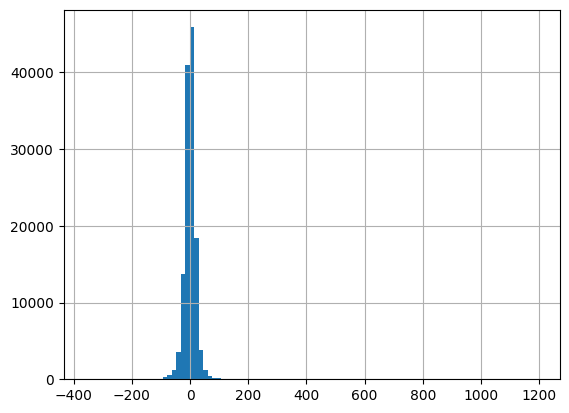

In [65]:
data_3weeks.liters_L.hist(bins=100)

In [66]:
data_3weeks.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,age,education_level_cd,marital_status_cd,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,liters_L
2,2025-04-06 21:00:00+00:00,157611917,23,4035.710000,1.000000,Premium,7.000000,IOS,61.520000,2025-03-07,...,NaN,NaN,NaN,NaN,NaN,4035.710000,65.599967,2025-03-07,1.000000,31.006395
4,2025-04-13 21:00:00+00:00,1076685894,49,507.770000,1.000000,Pro,0.000000,WEBVIEW_ANDROID,8.840000,2025-01-31,...,NaN,NaN,NaN,NaN,NaN,507.770000,57.440045,2025-01-31,0.000000,-21.673605
8,2025-04-06 21:00:00+00:00,391317842,19,314.190000,1.000000,No Subscription,0.000000,IOS,5.070000,2023-09-26,...,NaN,NaN,NaN,NaN,NaN,314.190000,61.970414,2023-09-26,1.000000,-25.443605
9,2025-04-06 21:00:00+00:00,232066824,19,1378.610000,1.000000,Pro,0.000000,ANDROID,25.530000,2024-04-07,...,NaN,NaN,NaN,NaN,NaN,1378.610000,53.999608,2024-04-07,1.000000,-4.983605
15,2025-04-06 21:00:00+00:00,402425070,19,4584.180000,2.000000,No Subscription,0.000000,ANDROID,59.730000,2025-04-08,...,NaN,NaN,NaN,NaN,NaN,2292.090000,76.748368,2025-04-08,0.000000,-1.297211


In [67]:
data = data.merge(
    data_3weeks[['party_rk', 'week', 'liters_L']],
    on=['party_rk', 'week'],
    how='left'
)
data.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,mean_price,meanperliter,fisrt_order_date,retention_4weeks,service_fee_to_gmv_ratio,service_fee_to_gmv_L,proportion,service_fee_changed_future,age_group,liters_L
0,2025-04-20 21:00:00+00:00,12103,29,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,2196.400000,54.910000,2024-05-07,1,0.013203,-13.689601,low_fee,1,NaN,9.486395
1,2025-04-20 21:00:00+00:00,14045,69,4427.300000,2.000000,Pro,0.000000,ANDROID,71.800000,2023-07-08,...,2213.650000,61.661560,2023-07-08,1,0.022886,8.089775,medium_fee,1,NaN,10.772789
2,2025-04-06 21:00:00+00:00,15150,29,2470.980000,1.000000,No Subscription,5.000000,ANDROID,39.990000,2024-05-16,...,2470.980000,61.789947,2024-05-16,1,0.011736,-19.026384,low_fee,1,NaN,9.476395
3,2025-04-06 21:00:00+00:00,17433,39,2479.600000,1.000000,Pro,3.000000,ANDROID,40.000000,2025-01-26,...,2479.600000,61.990000,2025-01-26,1,0.015728,-9.193924,medium_fee,1,50+,9.486395
4,2025-04-20 21:00:00+00:00,22290,49,2583.600000,1.000000,Premium,0.000000,ANDROID,40.000000,2020-09-17,...,2583.600000,64.590000,2020-09-17,1,0.018207,-3.307589,medium_fee,1,50+,9.486395


In [68]:
data['liters_group'] = pd.qcut(
    data['liters_L'],
    q=[0, 0.33, 0.67, 1],
    labels=['small', 'medium', 'big']
)

In [69]:
data.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,meanperliter,fisrt_order_date,retention_4weeks,service_fee_to_gmv_ratio,service_fee_to_gmv_L,proportion,service_fee_changed_future,age_group,liters_L,liters_group
0,2025-04-20 21:00:00+00:00,12103,29,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,54.910000,2024-05-07,1,0.013203,-13.689601,low_fee,1,NaN,9.486395,big
1,2025-04-20 21:00:00+00:00,14045,69,4427.300000,2.000000,Pro,0.000000,ANDROID,71.800000,2023-07-08,...,61.661560,2023-07-08,1,0.022886,8.089775,medium_fee,1,NaN,10.772789,big
2,2025-04-06 21:00:00+00:00,15150,29,2470.980000,1.000000,No Subscription,5.000000,ANDROID,39.990000,2024-05-16,...,61.789947,2024-05-16,1,0.011736,-19.026384,low_fee,1,NaN,9.476395,big
3,2025-04-06 21:00:00+00:00,17433,39,2479.600000,1.000000,Pro,3.000000,ANDROID,40.000000,2025-01-26,...,61.990000,2025-01-26,1,0.015728,-9.193924,medium_fee,1,50+,9.486395,big
4,2025-04-20 21:00:00+00:00,22290,49,2583.600000,1.000000,Premium,0.000000,ANDROID,40.000000,2020-09-17,...,64.590000,2020-09-17,1,0.018207,-3.307589,medium_fee,1,50+,9.486395,big


In [70]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='liters_group')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/1342763902.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='liters_group')


mean                  
liters_group    small   medium      big
proportion                             
no_fee       0.899972 0.895105 0.908096
low_fee      0.883910 0.903935 0.911841
medium_fee   0.889258 0.900606 0.909819
high_fee     0.859788 0.885179 0.899973

In [71]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['count'], columns='liters_group')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/3592949124.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['count'], columns='liters_group')


count              
liters_group  small medium    big
proportion                       
no_fee         3619   2860   2285
low_fee         491   4549  11207
medium_fee     8127   8904   6864
high_fee      11882   8535   3759

вот тут прикольно, хочется посмотреть на статзначимость 

In [72]:
groups = ['small', 'medium', 'big']

from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations


for group in groups:
    group_stats = data[data['liters_group'] == group].groupby('proportion').agg(
        returned_count=('retention_4weeks', 'sum'),
        total=('retention_4weeks', 'count')
    )

    results = []

    for g1, g2 in combinations(group_stats.index, 2):
        count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
        nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
        z_stat, p_val = proportions_ztest(count, nobs)

        results.append({
            "group_1": g1,
            "group_2": g2,
            "ret_1": count[0] / nobs[0],
            "ret_2": count[1] / nobs[1],
            "z_stat": z_stat,
            "p_value": p_val
        })

    results_df = pd.DataFrame(results)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print(f'Для группы {group} по литражу:')
    print(results_df)

Для группы small по литражу:
      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.859788 0.883910 -1.512960 0.130290
1    high_fee  medium_fee 0.859788 0.889258 -6.123017 0.000000
2    high_fee      no_fee 0.859788 0.899972 -6.276404 0.000000
3     low_fee  medium_fee 0.883910 0.889258 -0.366246 0.714182
4     low_fee      no_fee 0.883910 0.899972 -1.103763 0.269696
5  medium_fee      no_fee 0.889258 0.899972 -1.731317 0.083395
Для группы medium по литражу:
      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.885179 0.903935 -3.287847 0.001010
1    high_fee  medium_fee 0.885179 0.900606 -3.295486 0.000983
2    high_fee      no_fee 0.885179 0.895105 -1.454916 0.145693
3     low_fee  medium_fee 0.903935 0.900606  0.613535 0.539522
4     low_fee      no_fee 0.903935 0.895105  1.236293 0.216350
5  medium_fee      no_fee 0.900606 0.895105  0.850469 0.395064
Для группы big по литражу:
      group_1     group_2    ret

In [73]:
data.week.unique()

<DatetimeArray>
['2025-04-20 21:00:00+00:00', '2025-04-06 21:00:00+00:00',
 '2025-04-13 21:00:00+00:00']
Length: 3, dtype: datetime64[ns, UTC]

In [74]:
data[(data.proportion == 'high_fee') & (data.liters_group == 'big')].service_fee_amt.unique()

array([69, 99, 59, 89, 79, 19, 49, 39, 29])

In [75]:
data[(data.proportion == 'high_fee') & (data.service_fee_amt == 19)].shape

(1303, 29)

#### По платформам

In [76]:
'platform'

'platform'

In [77]:
data.platform.unique()

array(['ANDROID', 'WEBVIEW_IOS', 'WEB', 'IOS', 'WEBVIEW_ANDROID'],
      dtype=object)

In [78]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='platform', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

platform,ANDROID,IOS,WEB,WEBVIEW_ANDROID,WEBVIEW_IOS
proportion,,,,,
no_fee,0.889241,0.930874,0.810526,0.880000,0.886131
low_fee,0.911439,0.916620,0.840142,0.879676,0.914054
medium_fee,0.899476,0.910895,0.830853,0.869067,0.904796
high_fee,0.880743,0.873234,0.814371,0.836165,0.878989


In [79]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='platform', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

platform,ANDROID,IOS,WEB,WEBVIEW_ANDROID,WEBVIEW_IOS
proportion,,,,,
no_fee,5047,2792,190,50,685
low_fee,7317,3550,563,989,3828
medium_fee,11450,4938,739,1222,5546
high_fee,11689,4812,835,824,6016


In [80]:
data['is_web'] = data.platform.apply(lambda x: x in  ['WEBVIEW_IOS', 'WEB', 'WEBVIEW_ANDROID'])
data['is_ios'] = data.platform.apply(lambda x: x in  ['IOS', 'WEBVIEW_IOS'])

In [81]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='is_web')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

mean         
is_web        False    True 
proportion                  
no_fee     0.904069 0.870270
low_fee    0.913131 0.900000
medium_fee 0.902917 0.891701
high_fee   0.878553 0.867362

In [82]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', aggfunc=['mean'], columns='is_ios')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

mean         
is_ios        False    True 
proportion                  
no_fee     0.886325 0.922059
low_fee    0.903371 0.915289
medium_fee 0.892924 0.907669
high_fee   0.873839 0.876431

In [83]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

ios = data[data.is_ios == True]

group_stats = ios.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.876431 0.915289 -8.299066 0.000000
1    high_fee  medium_fee 0.876431 0.907669 -7.339204 0.000000
2    high_fee      no_fee 0.876431 0.922059 -7.408635 0.000000
3     low_fee  medium_fee 0.915289 0.907669  1.759369 0.078515
4     low_fee      no_fee 0.915289 0.922059 -1.196048 0.231678
5  medium_fee      no_fee 0.907669 0.922059 -2.585736 0.009717


In [84]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

android = data[data.is_ios == False]

group_stats = android.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.873839 0.903371 -6.773573 0.000000
1    high_fee  medium_fee 0.873839 0.892924 -4.863765 0.000001
2    high_fee      no_fee 0.873839 0.886325 -2.342636 0.019148
3     low_fee  medium_fee 0.903371 0.892924  2.512263 0.011996
4     low_fee      no_fee 0.903371 0.886325  3.227729 0.001248
5  medium_fee      no_fee 0.892924 0.886325  1.304217 0.192160


In [85]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

web = data[data.is_web == True]

group_stats = web.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.867362 0.900000 -5.665174 0.000000
1    high_fee  medium_fee 0.867362 0.891701 -4.604132 0.000004
2    high_fee      no_fee 0.867362 0.870270 -0.246638 0.805188
3     low_fee  medium_fee 0.900000 0.891701  1.516584 0.129372
4     low_fee      no_fee 0.900000 0.870270  2.731956 0.006296
5  medium_fee      no_fee 0.891701 0.870270  1.960494 0.049938


In [86]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

app = data[data.is_web == False]

group_stats = app.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.878553 0.913131 -9.028246 0.000000
1    high_fee  medium_fee 0.878553 0.902917 -7.080312 0.000000
2    high_fee      no_fee 0.878553 0.904069 -5.870332 0.000000
3     low_fee  medium_fee 0.913131 0.902917  2.842854 0.004471
4     low_fee      no_fee 0.913131 0.904069  2.129803 0.033188
5  medium_fee      no_fee 0.902917 0.904069 -0.283977 0.776428


#### По семейному положению

In [87]:
data.columns

Index(['week', 'party_rk', 'service_fee_amt', 'gmv', 'orders_cnt',
       'bundle_name', 'cashback_category', 'platform', 'liters',
       'first_order_date', 'entries_cnt', 'region', 'gender_cd', 'age',
       'education_level_cd', 'marital_status_cd', 'children_cnt', 'job_title',
       'mean_price', 'meanperliter', 'fisrt_order_date', 'retention_4weeks',
       'service_fee_to_gmv_ratio', 'service_fee_to_gmv_L', 'proportion',
       'service_fee_changed_future', 'age_group', 'liters_L', 'liters_group',
       'is_web', 'is_ios'],
      dtype='object')

In [88]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='marital_status_cd', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

marital_status_cd,CIV,DIV,MAR,UNM,WID
proportion,,,,,
no_fee,0.913462,0.911765,0.940625,0.915141,1.000000
low_fee,0.938462,0.892308,0.949060,0.943474,0.900000
medium_fee,0.902985,0.938053,0.929227,0.927842,0.900000
high_fee,0.892256,0.902542,0.911322,0.905730,1.000000


In [89]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='marital_status_cd', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

marital_status_cd,CIV,DIV,MAR,UNM,WID
proportion,,,,,
no_fee,104,68,640,601,4
low_fee,195,130,1276,973,10
medium_fee,268,226,1851,1566,10
high_fee,297,236,1793,1623,12


In [90]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

gr = data[data.marital_status_cd == 'MAR']

group_stats = gr.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.911322 0.949060 -3.961182 0.000075
1    high_fee  medium_fee 0.911322 0.929227 -1.996603 0.045868
2    high_fee      no_fee 0.911322 0.940625 -2.332905 0.019653
3     low_fee  medium_fee 0.949060 0.929227  2.248669 0.024534
4     low_fee      no_fee 0.949060 0.940625  0.772072 0.440072
5  medium_fee      no_fee 0.929227 0.940625 -0.988365 0.322974


#### По количеству детей))

In [91]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='children_cnt', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

children_cnt,0.000000,1.000000,2.000000,3.000000,4.000000,8.000000
proportion,,,,,,
no_fee,0.928101,0.913043,0.800000,1.000000,1.000000,NaN
low_fee,0.946213,0.946903,0.965909,1.000000,1.000000,NaN
medium_fee,0.931660,0.924855,0.877863,0.947368,0.800000,1.000000
high_fee,0.910158,0.888350,0.885496,1.000000,1.000000,NaN


In [92]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='children_cnt', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

children_cnt,0.000000,1.000000,2.000000,3.000000,4.000000,8.000000
proportion,,,,,,
no_fee,1669.000000,69.000000,35.000000,7.000000,4.000000,NaN
low_fee,3235.000000,113.000000,88.000000,9.000000,4.000000,NaN
medium_fee,4741.000000,173.000000,131.000000,19.000000,5.000000,1.000000
high_fee,4686.000000,206.000000,131.000000,19.000000,9.000000,NaN


In [93]:
data['have_children'] = data['children_cnt'].apply(lambda x: x > 0)

In [94]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='have_children', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

have_children,False,True
proportion,,
no_fee,0.900682,0.886957
low_fee,0.908127,0.957944
medium_fee,0.899304,0.905775
high_fee,0.874680,0.895890


In [95]:
pt = data.pivot_table(values='retention_4weeks', index='proportion', columns='have_children', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

have_children,False,True
proportion,,
no_fee,8649,115
low_fee,16033,214
medium_fee,23566,329
high_fee,23811,365


In [96]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

gr = data[data.have_children == True]

group_stats = gr.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.895890 0.957944 -2.639090 0.008313
1    high_fee  medium_fee 0.895890 0.905775 -0.434532 0.663902
2    high_fee      no_fee 0.895890 0.886957  0.271108 0.786308
3     low_fee  medium_fee 0.957944 0.905775  2.274061 0.022962
4     low_fee      no_fee 0.957944 0.886957  2.457845 0.013977
5  medium_fee      no_fee 0.905775 0.886957  0.581391 0.560977


In [97]:
data.pivot_table(values='retention_4weeks', index='proportion', columns=['age_group', 'have_children'], aggfunc='count')

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/3810095726.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data.pivot_table(values='retention_4weeks', index='proportion', columns=['age_group', 'have_children'], aggfunc='count')


age_group     18-29       30-39       40-49         50+      
have_children False True  False True  False True  False True 
proportion                                                   
high_fee       1881     9  2245   140  1367   154   748    62
low_fee         837     3  1689    82  1059    98   555    31
medium_fee     1634    11  2356   126  1408   148   759    44
no_fee          670     4   809    50   498    46   335    15

In [98]:
data.pivot_table(values='retention_4weeks', index='proportion', columns=['age_group', 'have_children'], aggfunc='mean')

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/2569215271.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data.pivot_table(values='retention_4weeks', index='proportion', columns=['age_group', 'have_children'], aggfunc='mean')


age_group        18-29             30-39             40-49               50+  \
have_children    False    True     False    True     False    True     False   
proportion                                                                     
high_fee      0.900053 0.888889 0.914922 0.892857 0.901975 0.883117 0.914439   
low_fee       0.940263 0.666667 0.944346 0.963415 0.945231 0.959184 0.954955   
medium_fee    0.931457 0.909091 0.932088 0.904762 0.933949 0.905405 0.938076   
no_fee        0.926866 0.750000 0.939431 0.920000 0.919679 0.869565 0.901493   

age_group               
have_children    True   
proportion              
high_fee      0.935484  
low_fee       0.967742  
medium_fee    0.909091  
no_fee        0.866667

In [99]:
# по возрасту статзначимость 
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

data4049 = df_age[df_age['age_group'] == '50+']

group_stats = data4049.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

      group_1     group_2    ret_1    ret_2    z_stat  p_value
0    high_fee     low_fee 0.916049 0.955631 -2.912477 0.003586
1    high_fee  medium_fee 0.916049 0.936488 -1.570087 0.116395
2    high_fee      no_fee 0.916049 0.900000  0.882080 0.377734
3     low_fee  medium_fee 0.955631 0.936488  1.539787 0.123612
4     low_fee      no_fee 0.955631 0.900000  3.336351 0.000849
5  medium_fee      no_fee 0.936488 0.900000  2.168339 0.030133


#### Переменная стабильности сервисного сбора

In [100]:
df = df.sort_values(['party_rk', 'week']).reset_index(drop=True)

# Предыдущее значение сбора и текущее
prev = df.groupby('party_rk')['service_fee_amt'].shift(1)
curr = df['service_fee_amt']

# Строковая переменная: "прошлое → текущее", для первой недели — NaN
df['change'] = prev.astype('Int64').astype(str) + ' → ' + curr.astype(int).astype(str)

# У первого наблюдения каждого клиента заменяем "nan → X" на NaN
df.loc[prev.isna(), 'change'] = pd.NA

In [101]:
def f(x):
    if x == 0:
        return 0
    if (x == 1) or (x == -1):
        return 1
    else:
        return np.nan

# Обязательно сортируем по клиенту и неделе
df = df.sort_values(['party_rk', 'week']).reset_index(drop=True)

# Считаем изменение сбора по сравнению с предыдущей заправкой клиента
df['change2'] = df.groupby('party_rk')['service_fee_amt'] \
                  .transform(lambda x: x.diff().fillna(pd.NA))

# Превращаем в 1 / 0 / -1
df['change2'] = np.sign(df['change2']).astype('Int64')  # Int64 сохраняет NaN
df['change_flg'] = df['change2'].apply(lambda x: f(x))

In [102]:
ddf = df[(df['week'] >= '2025-04-05') & (df['week'] <= '2025-04-21')]

In [119]:
metrics.columns

Index(['first_service_fee', 'avg_check', 'service_fee_to_gmv_ratio',
       'service_fee_to_gmv_L'],
      dtype='object')

<Axes: >

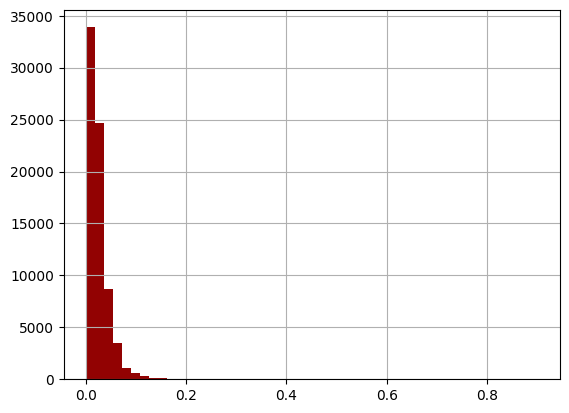

In [103]:
# средний сервисный сбор по пользователю
first_fee = (
    ddf.sort_values(['party_rk', 'week'])
      .groupby('party_rk')['service_fee_amt']
      .mean()
      .rename('first_service_fee')
)

# Средний чек = сумма gmv / сумма orders_cnt
avg_check = (
    ddf.groupby('party_rk')
      .apply(lambda x: x['gmv'].sum() / x['orders_cnt'].sum())
      .rename('avg_check')
)

# Собираем в одну таблицу
metrics = pd.concat([first_fee, avg_check], axis=1)

# Считаем итоговую метрику
metrics['service_fee_to_gmv_ratio'] = (
    metrics['first_service_fee'] / metrics['avg_check']
)

# Мержим обратно в исходный датафрейм
ddf = ddf.merge(
    metrics['service_fee_to_gmv_ratio'],
    left_on='party_rk',
    right_index=True,
    how='left'
)
ddf.head()

/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_12904/1334611444.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['gmv'].sum() / x['orders_cnt'].sum())


,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,children_cnt,job_title,mean_price,meanperliter,fisrt_order_date,retention_4weeks,change,change2,change_flg,service_fee_to_gmv_ratio
0,2025-04-06 21:00:00+00:00,12103,29,2196.400000,1.000000,No Subscription,0.000000,ANDROID,38.590000,2024-05-07,...,NaN,NaN,2196.400000,56.916300,2024-05-07,1.000000,<NA>,<NA>,NaN,0.013203
1,2025-04-20 21:00:00+00:00,12103,29,2196.400000,1.000000,No Subscription,0.000000,ANDROID,40.000000,2024-05-07,...,NaN,NaN,2196.400000,54.910000,2024-05-07,1.000000,29 → 29,0,0.000000,0.013203
5,2025-04-06 21:00:00+00:00,14045,23,2553.580000,1.000000,Pro,0.000000,ANDROID,41.280000,2023-07-08,...,NaN,NaN,2553.580000,61.859981,2023-07-08,1.000000,<NA>,<NA>,NaN,0.022886
6,2025-04-13 21:00:00+00:00,14045,69,2398.930000,1.000000,Pro,0.000000,ANDROID,38.780000,2023-07-08,...,NaN,NaN,2398.930000,61.859979,2023-07-08,1.000000,23 → 69,1,1.000000,0.022886
7,2025-04-20 21:00:00+00:00,14045,69,4427.300000,2.000000,Pro,0.000000,ANDROID,71.800000,2023-07-08,...,NaN,NaN,2213.650000,61.661560,2023-07-08,1.000000,69 → 69,0,0.000000,0.022886


In [104]:
# Считаем константу c
c = metrics['first_service_fee'].sum() / metrics['avg_check'].sum()

# Линеаризация
metrics['service_fee_to_gmv_L'] = metrics['first_service_fee'] - c * metrics['avg_check']

In [105]:
ddf = ddf.merge(
    metrics[['service_fee_to_gmv_L']],
    left_on='party_rk',
    right_index=True,
    how='left'
)

In [106]:
q33 = ddf['service_fee_to_gmv_L'].quantile(0.33)
q67 = ddf['service_fee_to_gmv_L'].quantile(0.67)

def proportion_group(fee, l, q33, q67):
    if fee == 0:
        return 'no_fee'
    elif l <= q33:
        return 'low_fee'
    elif l <= q67:
        return 'medium_fee'
    else:
        return 'high_fee'

In [107]:
conditions = [
    ddf['service_fee_amt'] == 0,
    ddf['service_fee_to_gmv_L'] <= q33,
    ddf['service_fee_to_gmv_L'] <= q67
]

choices = ['no_fee', 'low_fee', 'medium_fee']
ddf['proportion'] = np.select(conditions, choices, default='high_fee')


In [108]:
# оставляем последнюю запись для каждого пользователя, чтобы посчитать retention по ней
last_idx = ddf.groupby('party_rk')['week'].idxmax()
ddf = ddf.loc[last_idx].reset_index(drop=True)

In [109]:
pt = ddf.pivot_table(values='retention_4weeks', index='proportion', columns='change2', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

change2,-1,0,1
proportion,,,
no_fee,0.888186,0.895725,NaN
low_fee,0.916239,0.900509,0.885434
medium_fee,0.889831,0.892865,0.874902
high_fee,0.912837,0.859266,0.840435


In [110]:
pt = ddf.pivot_table(values='retention_4weeks', index='proportion', columns='change2', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

change2,-1,0,1
proportion,,,
no_fee,474.000000,6128.000000,NaN
low_fee,1170.000000,8644.000000,2348.000000
medium_fee,1180.000000,13217.000000,3813.000000
high_fee,1262.000000,12584.000000,4600.000000


In [111]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

gr = data[data.have_children == True]

group_stats = gr.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []


count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
z_stat, p_val = proportions_ztest(count, nobs)

In [112]:
pt = ddf.pivot_table(values='retention_4weeks', index='proportion', columns='change2', aggfunc='count')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

change2,-1,0,1
proportion,,,
no_fee,474.000000,6128.000000,NaN
low_fee,1170.000000,8644.000000,2348.000000
medium_fee,1180.000000,13217.000000,3813.000000
high_fee,1262.000000,12584.000000,4600.000000


In [113]:
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

gr = ddf[ddf.change2 == 1]

group_stats = gr.groupby('proportion').agg(
    returned_count=('retention_4weeks', 'sum'),
    total=('retention_4weeks', 'count')
)

results = []

for g1, g2 in combinations(group_stats.index, 2):
    count = [group_stats.loc[g1, 'returned_count'], group_stats.loc[g2, 'returned_count']]
    nobs = [group_stats.loc[g1, 'total'], group_stats.loc[g2, 'total']]
    z_stat, p_val = proportions_ztest(count, nobs)

    results.append({
        "group_1": g1,
        "group_2": g2,
        "ret_1": count[0] / nobs[0],
        "ret_2": count[1] / nobs[1],
        "z_stat": z_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)

pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print(results_df)

    group_1     group_2    ret_1    ret_2    z_stat  p_value
0  high_fee     low_fee 0.840435 0.885434 -5.048245 0.000000
1  high_fee  medium_fee 0.840435 0.874902 -4.483230 0.000007
2   low_fee  medium_fee 0.885434 0.874902  1.230783 0.218404


In [114]:
pt = ddf.pivot_table(values='retention_4weeks', index='proportion', columns='change_flg', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

change_flg,0.000000,1.000000
proportion,,
no_fee,0.895725,0.888186
low_fee,0.900509,0.895679
medium_fee,0.892865,0.878430
high_fee,0.859266,0.856022


#### Проверка на устойчивость по change2  НЕ СМОТРЕТЬ ПОЖАЛУЙСТА ФИГНЯ

In [115]:
user_counts = dddf.groupby('party_rk').size()
single_users = user_counts[user_counts == 1].index  

dddf_single = dddf[dddf['party_rk'].isin(single_users)].reset_index(drop=True)

NameError: name 'dddf' is not defined

In [ ]:
dddf = dddf[(dddf['week'] >= '2025-04-05') & (dddf['week'] <= '2025-04-21')]

In [ ]:
dddf = df[(df['week'] >= '2025-04-05') & (df['week'] <= '2025-04-21')].copy()

user_counts = dddf.groupby('party_rk').size()
single_users = user_counts[user_counts == 1].index  

dddf_single = dddf[dddf['party_rk'].isin(single_users)].reset_index(drop=True)

In [ ]:
dddf_single.head()

,week,party_rk,service_fee_amt,gmv,orders_cnt,bundle_name,cashback_category,platform,liters,first_order_date,...,mean_price,meanperliter,fisrt_order_date,retention_4weeks,change,change2,change_flg,service_fee_to_gmv_ratio,service_fee_to_gmv_L,proportion
0,2025-04-06 21:00:00+00:00,15150,29,2470.980000,1.000000,No Subscription,5.000000,ANDROID,39.990000,2024-05-16,...,2470.980000,61.789947,2024-05-16,1.000000,<NA>,<NA>,NaN,0.011736,-19.026384,low_fee
1,2025-04-06 21:00:00+00:00,17433,39,2479.600000,1.000000,Pro,3.000000,ANDROID,40.000000,2025-01-26,...,2479.600000,61.990000,2025-01-26,1.000000,23 → 39,1,1.000000,0.015728,-9.193924,medium_fee
2,2025-04-20 21:00:00+00:00,26770,29,2770.660000,1.000000,Pro,5.000000,ANDROID,47.080000,2023-09-08,...,2770.660000,58.850042,2023-09-08,1.000000,<NA>,<NA>,NaN,0.010467,-24.851015,low_fee
3,2025-04-06 21:00:00+00:00,27864,23,2350.560000,1.000000,Pro,0.000000,ANDROID,35.870000,2023-03-27,...,2350.560000,65.529969,2023-03-27,1.000000,23 → 23,0,0.000000,0.009785,-22.685880,low_fee
4,2025-04-13 21:00:00+00:00,35871,39,2519.600000,1.000000,Pro,4.000000,ANDROID,40.000000,2023-09-10,...,2519.600000,62.990000,2023-09-10,1.000000,23 → 39,1,1.000000,0.015479,-9.971370,medium_fee


In [ ]:
# средний сервисный сбор по пользователю
first_fee = (
    dddf.sort_values(['party_rk', 'week'])
      .groupby('party_rk')['service_fee_amt']
      .mean()
      .rename('first_service_fee')
)

# Средний чек = сумма gmv / сумма orders_cnt
avg_check = (
    dddf.groupby('party_rk')
      .apply(lambda x: x['gmv'].sum() / x['orders_cnt'].sum())
      .rename('avg_check')
)

# Собираем в одну таблицу
metrics = pd.concat([first_fee, avg_check], axis=1)

# Считаем итоговую метрику
metrics['service_fee_to_gmv_ratio'] = (
    metrics['first_service_fee'] / metrics['avg_check']
)

# Мержим обратно в исходный датафрейм
dddf = dddf.merge(
    metrics['service_fee_to_gmv_ratio'],
    left_on='party_rk',
    right_index=True,
    how='left'
)

# Считаем константу c
c = metrics['first_service_fee'].sum() / metrics['avg_check'].sum()

# Линеаризация
metrics['service_fee_to_gmv_L'] = metrics['first_service_fee'] - c * metrics['avg_check']


/var/folders/g2/xgmmmhrx249fy99vwk1f8jmr0000gp/T/ipykernel_46623/2360695375.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['gmv'].sum() / x['orders_cnt'].sum())


In [ ]:
dddf = dddf.merge(
    metrics[['service_fee_to_gmv_L']],
    left_on='party_rk',
    right_index=True,
    how='left'
)

conditions = [
    dddf['service_fee_amt'] == 0,
    dddf['service_fee_to_gmv_L'] <= q33,
    dddf['service_fee_to_gmv_L'] <= q67
]

choices = ['no_fee', 'low_fee', 'medium_fee']
dddf['proportion'] = np.select(conditions, choices, default='high_fee')

In [ ]:
pt = dddf_single.pivot_table(values='retention_4weeks', index='proportion', columns='change2', aggfunc='mean')
order = ['no_fee', 'low_fee', 'medium_fee', 'high_fee']
pt.index = pd.CategoricalIndex(pt.index, categories=order, ordered=True)

pt_sorted = pt.sort_index()
pt_sorted

change2,-1,0,1
proportion,,,
no_fee,0.852679,0.847233,NaN
low_fee,0.911828,0.849091,0.884559
medium_fee,0.879562,0.819639,0.894700
high_fee,0.454545,0.890909,0.844728
